# Transcription-factor motif activity with chromVAR

Gene-activity scores ([tutorial 2](t_epi_02_atac_clustering_annotation)) tell you *which genes*
are accessible. **chromVAR** (Schep et al., *Nat. Methods* 2017) asks a complementary question:
*which transcription factors* are driving the accessibility differences between cells. For every
TF motif it computes a per-cell **deviation z-score** — how much more (or less) accessible the
peaks containing that motif are, relative to a GC/accessibility-matched background.

This tutorial runs the full chromVAR pipeline with `ov.epi` on the 10x PBMC-500 scATAC dataset:

1. preprocess fragments → tiles → clusters (the [tutorial 1](t_epi_01_atac_preprocess) flow, condensed)
2. call peaks per cluster with MACS3 (`ov.epi.single.macs3`) and merge them (`ov.epi.io.merge_peaks`)
3. build a cell × peak matrix (`ov.epi.pp.make_peak_matrix`)
4. annotate peaks with JASPAR motifs (`ov.epi.tl.add_motif_matrix`)
5. sample background peaks (`ov.epi.tl.add_background_peaks`) and compute deviations
   (`ov.epi.tl.compute_deviations`)
6. rank the most variable TFs and visualise their activity

> **Heads-up on runtime.** Steps 4–5 download the GRCh38 FASTA (~1 GB, one-time) and scan ~900
> JASPAR motifs over the peak set, which takes several minutes on CPU. Everything is cached, so
> re-runs are fast.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1


## 1 · Preprocess (condensed)

Same ingest → QC → tiles → iterative-LSI → clusters flow as tutorial 1, on the PBMC-500
fragments. chromVAR itself doesn't need clusters, but we use them both to call peaks and to
summarise TF activity per group.

In [2]:
genome = ov.epi.data.hg38
genes = ov.epi.io.get_gene_annotation(genome)

frag = ov.epi.datasets.atac_pbmc500_fragments()
work = os.path.join(os.getcwd(), 'data_epi')
os.makedirs(work, exist_ok=True)
h5 = os.path.join(work, 'pbmc500_chromvar.h5ad')
if os.path.exists(h5):
    os.remove(h5)

adata = ov.epi.pp.import_fragments(str(frag), chrom_sizes=genome, file=h5, min_num_fragments=500)
ov.epi.pp.tsse(adata, genes)
adata = ov.epi.pp.qc(adata, tresh={
    'fragment_counts_min': 1000, 'fragment_counts_max': 100000,
    'TSS_score_min': 2.0, 'TSS_score_max': 100.0, 'Nucleosome_singal_max': 4.0})
ov.epi.pp.add_tile_matrix(adata, bin_size=500)
ov.epi.pp.select_features(adata, n_features=250000)
ov.epi.tl.iterative_lsi(adata, n_components=20, iterations=2)
ov.epi.pp.neighbors(adata, use_rep='X_iterative_lsi')
ov.epi.tl.clusters(adata, method='leiden', use_rep='X_iterative_lsi', key_added='clusters')
ov.epi.tl.umap(adata)
print('cells:', adata.n_obs, '| clusters:', ov.epi.utils.obs_to_pandas(adata)['clusters'].nunique())

└─ scanning /tmp/snapatac2/atac_pbmc_500.tsv.gz


  └─ imported 646 cells  (9,899,673 unique fragments)


└─ Computing TSS enrichment score for adata...
└─ Computing TSS enrichment score for adata...


Fetching Regions...:   0%|                                                                                        | 0/19978 [00:00<?, ?it/s]

Fetching Regions...:   0%|▍                                                                             | 97/19978 [00:00<00:20, 960.55it/s]

...

    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


  └─ [iterative_lsi]   -> 7 clusters; selected 25,000 variable features for next round
  └─ [iterative_lsi] Iter 2/2 | fit on 567 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (567 x 19) in adata.obsm['X_iterative_lsi']
Computing neighbors with n_neighbors=15


Finished computing neighbors
    Added to .uns['neighbors']
    .obsp['distances'], distances for each pair of neighbors
    .obsp['connectivities'], weighted adjacency matrix
Running Leiden clustering with leidenalg...
    Finished: found 9 clusters
    Added 'clusters' to adata.obs (categorical)
Computing UMAP embedding...


    Finished computing UMAP
    Added:
        'X_umap', UMAP coordinates (adata.obsm)
        'umap', UMAP parameters (adata.uns)
cells: 567 | clusters: 9


## 2 · Peak calling and a cell × peak matrix

chromVAR works on **peaks**, not genome tiles. We call peaks per cluster with MACS3, merge them
into a single non-overlapping ArchR-style peak set, and count fragments per cell per peak.

In [3]:
peaks = ov.epi.single.macs3(adata, groupby='clusters', qvalue=0.1, inplace=False)
if peaks is None:
    peaks = adata.uns['macs3']
merged = ov.epi.io.merge_peaks(peaks, chrom_sizes=genome)
print('merged peak set:', merged.shape)

pk = ov.epi.pp.make_peak_matrix(adata, merged)
# carry the embedding/clusters over for plotting
obs = ov.epi.utils.obs_to_pandas(adata)
pk.obsm['X_umap'] = adata.obsm['X_umap']
pk.obs['clusters'] = obs.loc[list(pk.obs_names), 'clusters'].values
print('cell x peak matrix:', pk.shape)

└─ MACS3 peak calling: 9 group(s)


  └─   calling peaks for '0' (109 cells)


  └─   calling peaks for '1' (108 cells)


  └─   calling peaks for '2' (97 cells)


  └─   calling peaks for '3' (57 cells)


...

  └─   calling peaks for '7' (40 cells)


  └─   calling peaks for '8' (14 cells)


  └─ merged 107,793 non-overlapping peaks
merged peak set: (107793, 5)


└─ building peak matrix: 567 cells × 107,793 peaks


  └─ peak matrix nnz=4,228,286
cell x peak matrix: (567, 107793)


## 3 · Motif annotation

`ov.epi.tl.add_motif_matrix` scans each peak for JASPAR motif matches (default JASPAR2024 CORE
vertebrates) using the genome FASTA, producing a binary peak × motif matrix in
`pk.varm['motif']`.

In [4]:
fasta = genome.fasta() if callable(getattr(genome, 'fasta', None)) else genome.fasta
ov.epi.tl.add_motif_matrix(pk, genome_fasta=str(fasta))
print('peak x motif matrix:', pk.varm['motif'].shape)
print('n motifs:', len(pk.uns['motif_names']))

  └─ [motif_matrix] reading sequences from /tmp/snapatac2/gencode_v41_GRCh38.fa.gz.decomp


  0%|                                                                                                            | 0/107793 [00:00<?, ?it/s]

 17%|███████████████▋                                                                            | 18325/107793 [00:00<00:00, 183232.70it/s]

 34%|███████████████████████████████▎                                                            | 36668/107793 [00:00<00:00, 183344.74it/s]

 52%|███████████████████████████████████████████████▊                                            | 56014/107793 [00:00<00:00, 187960.24it/s]

...

100%|████████████████████████████████████████████████████████████████████████████████████████████▉| 107658/107793 [01:41<00:00, 1073.30it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████▉| 107768/107793 [01:41<00:00, 1080.03it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 107793/107793 [01:41<00:00, 1059.57it/s]

  └─ [motif_matrix] 8,126,936 (peak, motif) hits | median per motif: 6,985


peak x motif matrix: (107793, 879)
n motifs: 879


## 4 · Background peaks and per-cell deviations

chromVAR corrects for GC content and overall accessibility by comparing each motif's peaks to a
matched set of background peaks. `add_background_peaks` samples them (using the FASTA for GC),
then `compute_deviations` returns the per-cell z-scores in `pk.obsm['motif_deviations']`.

In [5]:
ov.epi.tl.add_background_peaks(pk, n_iterations=25, genome_fasta=str(fasta), seed=1)
ov.epi.tl.compute_deviations(pk, motif_key='motif', bg_key='bg_peaks', method='analytical')

Z = np.asarray(pk.obsm['motif_deviations'])
tf_names = np.asarray(pk.uns['motif_deviations_names'])
print('deviation z-scores:', Z.shape, '| TFs:', len(tf_names))

  └─ [bg_peaks] computing GC bias


  0%|                                                                                                            | 0/107793 [00:00<?, ?it/s]

 16%|██████████████▎                                                                             | 16833/107793 [00:00<00:00, 168316.12it/s]

 31%|████████████████████████████▊                                                               | 33822/107793 [00:00<00:00, 169237.01it/s]

 47%|███████████████████████████████████████████▍                                                | 50845/107793 [00:00<00:00, 169686.05it/s]

...

  └─ [deviations] observed deviation (M @ X_dense)


  └─ [deviations] analytical null | fused peer-stats (numba prange, local buf)


  └─ [deviations] analytical null | M @ (μ, σ²) fused sgemm


  └─ [deviations] done. obsm['motif_deviations'] = (567, 879) float32 Z-scores; [motif_deviations_raw] holds uncorrected deviations


deviation z-scores: (567, 879) | TFs: 879


## 5 · Most variable transcription factors

Ranking motifs by the variance of their z-score across cells surfaces the TFs whose activity
varies most — the candidate drivers of cell-state differences.

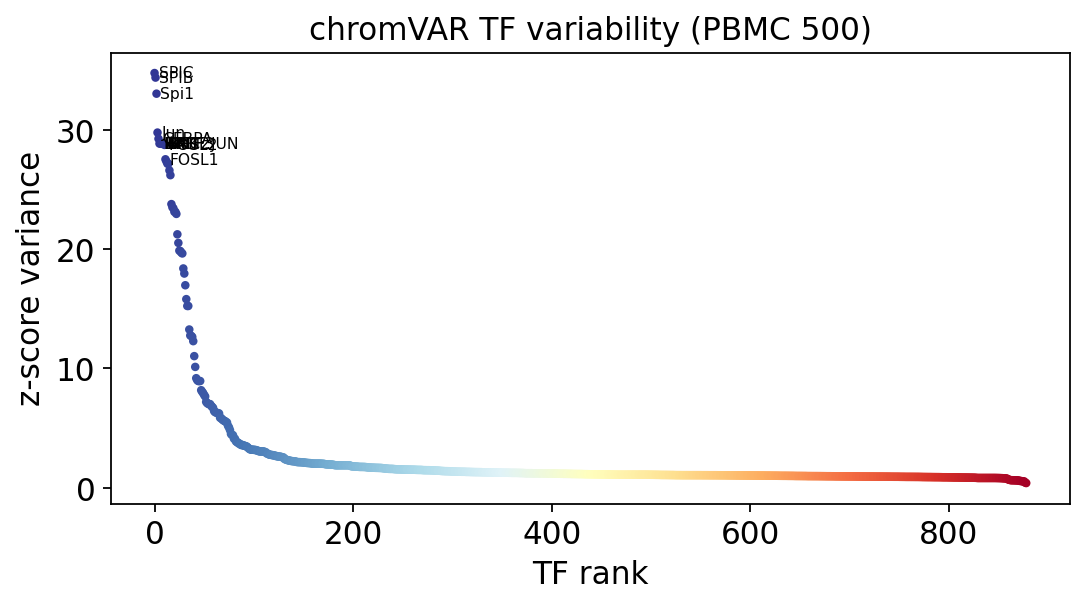

In [6]:
variability = np.nanvar(Z, axis=0)
rank = np.argsort(-variability)

def tf_label(n):
    # JASPAR names look like 'MA0492.1_JUND' -> show the gene symbol.
    return str(n).split('_', 1)[-1]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(variability))
ax.scatter(x, variability[rank], s=8,
           c=plt.cm.RdYlBu_r(np.linspace(0, 1, len(x))))
for i in range(12):
    ax.text(x[i] + 4, variability[rank][i], tf_label(tf_names[rank[i]]),
            fontsize=7, va='center')
ax.set_xlabel('TF rank'); ax.set_ylabel('z-score variance')
ax.set_title('chromVAR TF variability (PBMC 500)')
plt.tight_layout(); plt.show()

### TF activity on the UMAP

Colouring the UMAP by the deviation z-score of the top variable TFs shows their activity
localising to specific cell populations.

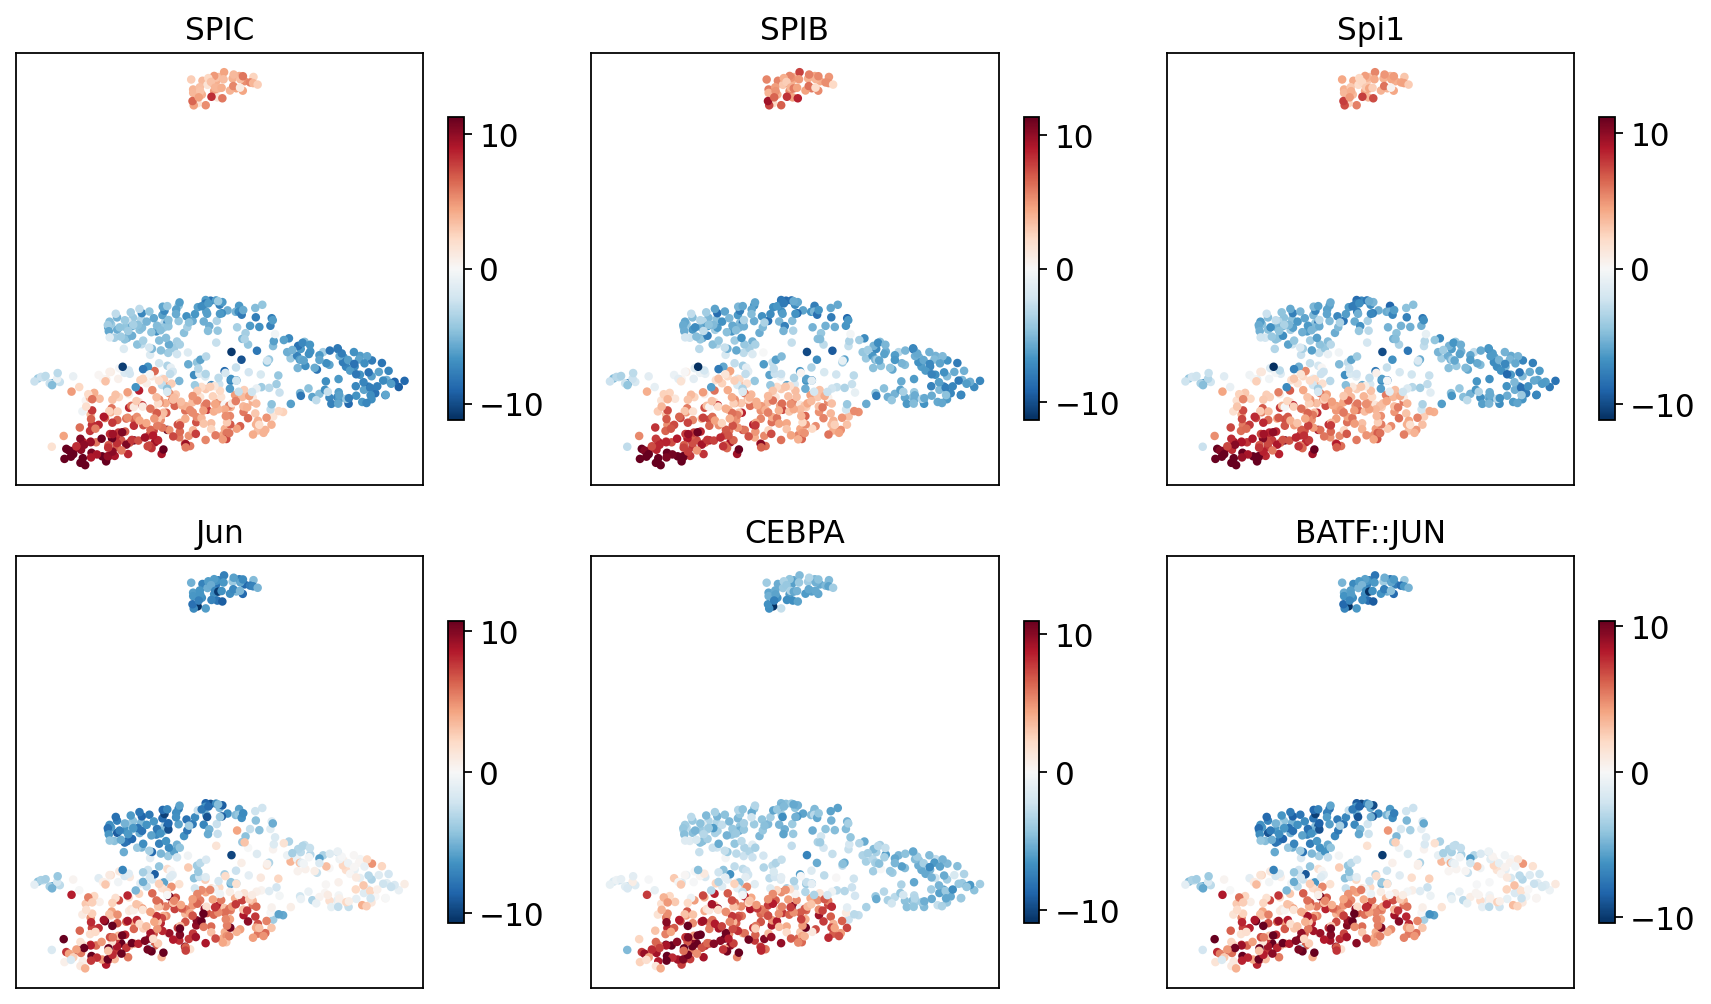

In [7]:
um = pk.obsm['X_umap']
top = [int(i) for i in rank[:6]]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5))
for ax, j in zip(axes.ravel(), top):
    v = Z[:, j]
    lim = np.nanpercentile(np.abs(v), 98)
    sc = ax.scatter(um[:, 0], um[:, 1], s=8, c=v, cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(tf_label(tf_names[j])); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

### Cluster × TF activity heatmap

Mean deviation per (cluster, TF) for the top variable TFs — the chromVAR analogue of a marker
heatmap, here in terms of transcription-factor motif activity.

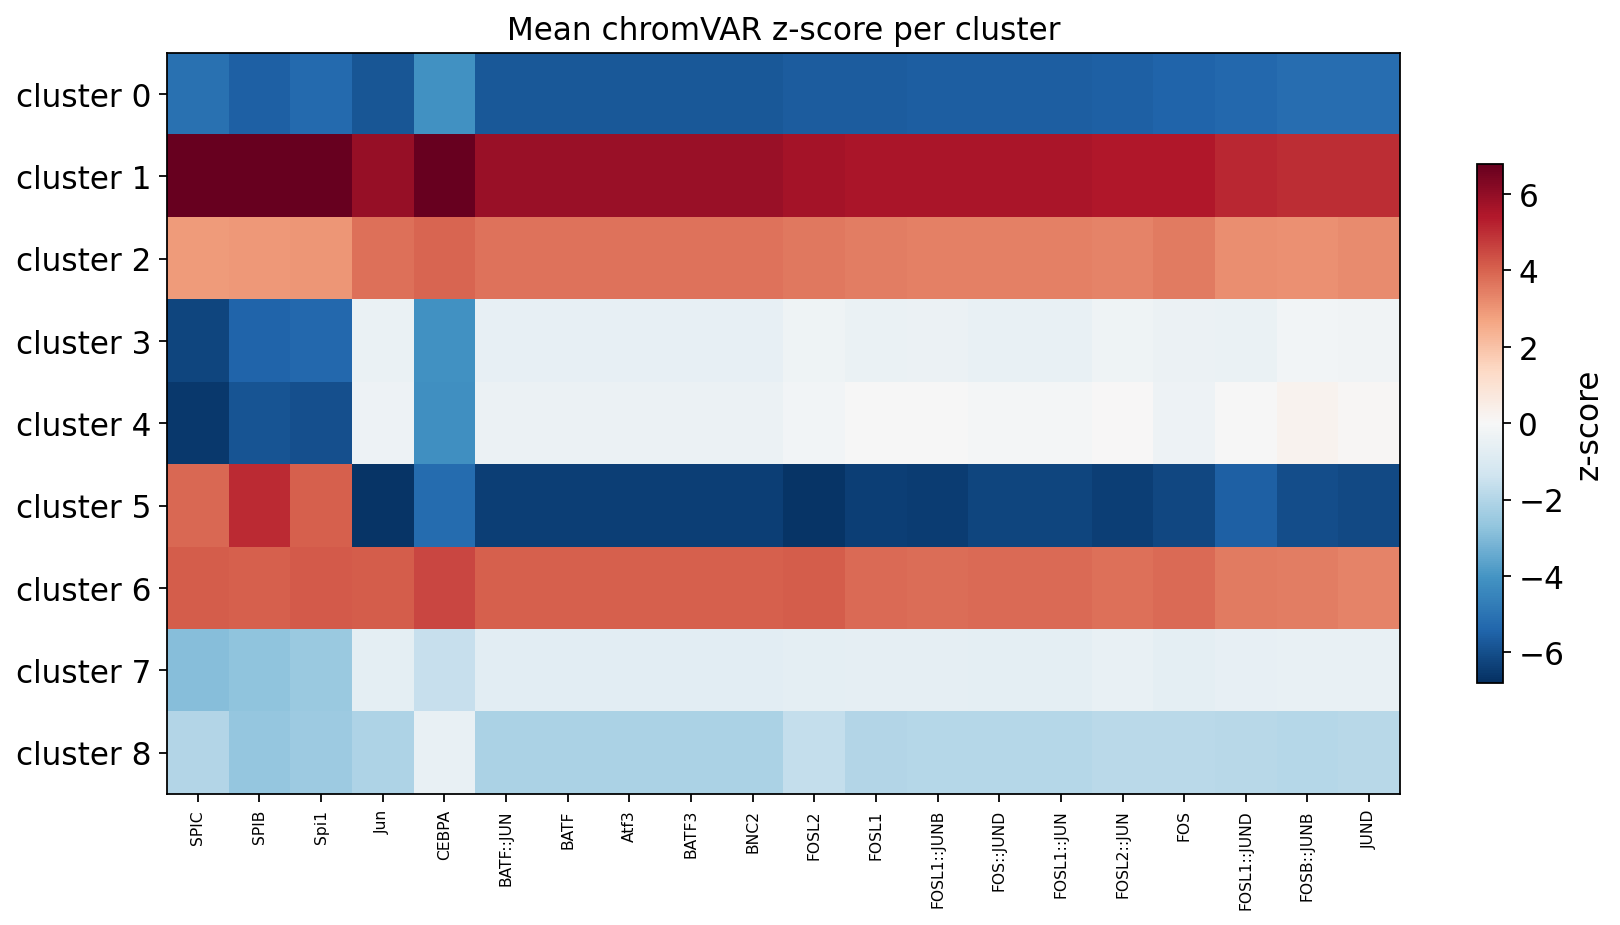

In [8]:
top_n = 20
tf_idx = [int(i) for i in rank[:top_n]]
clu = pk.obs['clusters'].astype('category')
cats = list(clu.cat.categories)
heat = np.stack([np.nanmean(Z[clu.values == c][:, tf_idx], axis=0) for c in cats])

fig, ax = plt.subplots(figsize=(0.45 * top_n + 2, 0.5 * len(cats) + 1.5))
lim = np.nanpercentile(np.abs(heat), 98)
im = ax.imshow(heat, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
ax.set_xticks(range(top_n)); ax.set_xticklabels([tf_label(tf_names[j]) for j in tf_idx],
                                                rotation=90, fontsize=7)
ax.set_yticks(range(len(cats))); ax.set_yticklabels([f'cluster {c}' for c in cats])
ax.set_title('Mean chromVAR z-score per cluster')
plt.colorbar(im, ax=ax, label='z-score', shrink=0.7)
plt.tight_layout(); plt.show()

## Summary

| stage | function |
|---|---|
| peaks per cluster | `ov.epi.single.macs3` |
| merge peaks | `ov.epi.io.merge_peaks` |
| cell × peak matrix | `ov.epi.pp.make_peak_matrix` |
| motif annotation | `ov.epi.tl.add_motif_matrix` |
| background peaks | `ov.epi.tl.add_background_peaks` |
| deviations | `ov.epi.tl.compute_deviations` → `obsm['motif_deviations']` |

Together the three epigenetics tutorials cover the core single-cell ATAC workflow with `ov.epi`:
quality control, embedding and annotation, gene-activity scores, and transcription-factor motif
activity — the same `pp` / `tl` / `pl` grammar as the rest of OmicVerse, now over the
[epione](https://github.com/aristoteleo/epione) epigenomics backend.